## Project Overview
EmporiUm is a growing student bookstore chain selling books, tech gear, art supplies, apparel, stationery, and more — both in-store and online. Sales are organized into regions, each containing multiple territories managed by a territory manager.
The two sales territories assigned to me are:

| | Territory 1 | Territory 2 |
|---|---|---|
| **Territory Manager** | Jim Heck | Ellen Lemon |
| **Region** | West | East |
| **Region Director** | Cassie Chambers | Ana Jilani |
| **State** | Colorado | Connecticut |
| **Number of Stores** | 18 | 8 |

**Data Period Covered:** January 1, 2022 — September 9, 2025 

In [1]:
# Import libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
import matplotlib.dates as mdates
import matplotlib.patches as mpatches 
import warnings
warnings.filterwarnings('ignore')

## Load CSV files:

In [2]:
# 1. Store Sales 
store_sales = pd.read_csv(r"C:\Users\malaikatariq\Desktop\My resources DA\capstone 2\StoreSales.csv")
store_sales.info()
print(f"Shape: {store_sales.shape[0]:,} rows x {store_sales.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB
Shape: 335,129 rows x 5 columns


In [3]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [4]:
# 2. Store Detail
store_detail = pd.read_csv(r"C:\Users\malaikatariq\Desktop\My resources DA\capstone 2\StoreDetail.csv")
store_detail.info()
print(f"Shape: {store_detail.shape[0]:,} rows x {store_detail.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB
Shape: 111 rows x 6 columns


In [5]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [6]:
# 3. Products
products = pd.read_csv (r"C:\Users\malaikatariq\Desktop\My resources DA\capstone 2\Products.csv")
products.info()
print(f"Shape: {products.shape[0]:,} rows x {products.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB
Shape: 669 rows x 4 columns


In [7]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
# 4. Product Categories
product_categories = pd.read_csv(r"C:\Users\malaikatariq\Desktop\My resources DA\capstone 2\ProductCategories.csv")
product_categories.info()
print(f"Shape: {product_categories.shape[0]:,} rows x {product_categories.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB
Shape: 52 rows x 4 columns


In [9]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [10]:
# 5. Customer List
customer_list = pd.read_csv(r"C:\Users\malaikatariq\Desktop\My resources DA\capstone 2\customer_list.csv", sep='|')
customer_list.info()
print(f"Shape: {customer_list.shape[0]:,} rows x {customer_list.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB
Shape: 521 rows x 7 columns


In [11]:
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Data Cleaning & Preparation:

In [38]:
# Step 1: Parse Transaction Dates

store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Year'] = store_sales['Transaction Date'].dt.year
store_sales['Month'] = store_sales['Transaction Date'].dt.month
store_sales['Quarter'] = store_sales['Transaction Date'].dt.quarter
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')

print("Date range:", store_sales["Transaction Date"].min().date(), "->", store_sales["Transaction Date"].max().date()) 
print("Unique months:", store_sales["YearMonth"].nunique())

Date range: 2022-01-01 -> 2025-12-31
Unique months: 48


In [13]:
# Step 2: Merge Products with Categories

prod_full = products.merge(
    product_categories[['CategoryID', 'SubcategoryID', 'Category', 'Subcategory']],
    on = ['CategoryID', 'SubcategoryID'],
    how='left'
)
print(f"Products with category labels: {len(prod_full):,}")
print("Categories:", prod_full['Category'].unique())

Products with category labels: 689
Categories: ['Technology & Accessories' 'Apparel and Merchandise' 'Textbooks'
 'Art Supplies' 'Books (General)' 'Stationery and Supplies' nan]


In [14]:
# Step 3: Merge Store Sales -> store Detail -> Product Categories

import gc

# Keep only the columns needed here to reduce memory usage 
store_sales_slim = store_sales[['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount', 'Year', 'Month', 'Quarter', 'YearMonth']]
store_detail_slim = store_detail[['Store Location', 'Store ID', 'Territory Manager', 'Region', 'State', 'Region Director']]
prod_slim = prod_full[['Prod Num', 'Category', 'Subcategory']]
                                
sales_stores = store_sales_slim.merge(store_detail_slim, on='Store ID', how='left')
del store_sales_slim, store_detail_slim
gc.collect()

sales_full = sales_stores.merge(prod_slim, on='Prod Num', how='left')
del sales_stores, prod_slim
gc.collect()

print(f" Master dataset: {sales_full.shape[0]:,} rows x {sales_full.shape[1]} columns")
print(f" Columns: {list(sales_full.columns)}")

# 5 products have no matching category entry - label them 'Unknown'
sales_full['Category'].fillna('Unknown', inplace=True)
sales_full['Subcategory'].fillna('Unknown', inplace=True)
print(f" Category nulls after fillna: {sales_full['Category'].isnull().sum()}")

 Master dataset: 347,364 rows x 16 columns
 Columns: ['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount', 'Year', 'Month', 'Quarter', 'YearMonth', 'Store Location', 'Territory Manager', 'Region', 'State', 'Region Director', 'Category', 'Subcategory']
 Category nulls after fillna: 0


In [42]:
# Step 4: Filter into our two cross-region territories for comparison

TERRITORY_WEST = 'Jim Heck'              # West Region - Colorado
TERRITORY_EAST = 'Ellen Lemon'         # East Region - Connecticut

jim_sales = sales_full[sales_full['Territory Manager'] == TERRITORY_WEST].copy()
ellen_sales = sales_full[sales_full['Territory Manager'] == TERRITORY_EAST].copy()

# Summary
print("=" * 80)
print(f" CROSS-REGION DATASET SUMMARY")
print("=" * 80)
print(f"{'Metric':<30} {'Jim Heck (West/CO)':>18} {'Ellen Lemon (East/CT)':>18}")
print("-" * 80)
print(f"{'Transactions':<30} {len(jim_sales):>18,} {len(ellen_sales):>18,}")
print(f"{'Total Revenue':<30}  ${jim_sales['Sale Amount'].sum():>16,.2f}  ${ellen_sales['Sale Amount'].sum():>16,.2f}")
print(f"{'Unique Stores':<30} {jim_sales['Store ID'].nunique():>18} {ellen_sales['Store ID'].nunique():>18}")
print(f"{'Unique Products Sold':<30} {jim_sales['Prod Num'].nunique():>18} {ellen_sales['Prod Num'].nunique():>18}")
print(f"{'Rewards Transactions':<30} {jim_sales['RewardsID'].notna().sum():>18,} {ellen_sales['RewardsID'].notna().sum():>18,}")
print("=" * 80)

 CROSS-REGION DATASET SUMMARY
Metric                         Jim Heck (West/CO) Ellen Lemon (East/CT)
--------------------------------------------------------------------------------
Transactions                               48,307             18,033
Total Revenue                   $    6,465,821.91  $    2,410,901.11
Unique Stores                                  18                  8
Unique Products Sold                          582                580
Rewards Transactions                        5,058              1,936


# Core Marketing Analysis

### Question 1 — Territory Managers, Store IDs & Cities
*Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?*

In [16]:
jim_stores = store_detail[store_detail['Territory Manager'] == TERRITORY_WEST]  [['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region', 'Region Director']].sort_values('Store ID').reset_index(drop=True)  
ellen_stores = store_detail[store_detail['Territory Manager'] == TERRITORY_EAST]  [['Store ID', 'Store Location', 'State', 'Territory Manager', 'Region', 'Region Director']].sort_values('Store ID').reset_index(drop=True)  

# Territory 1: Colorado (West Region)

print("=" * 55)
print(f" TERRITORY 1 - WEST REGION (COLORADO)")
print("=" * 55)
print(f" Territory Manager : {jim_stores['Territory Manager'].iloc[0]:<45}")
print(f" Region: {jim_stores['Region'].iloc[0]:<45}")
print(f" Region Director : {jim_stores['Region Director'].iloc[0]:<45}")
print(f" Number of Stores : {len(jim_stores):<45}")
print("=" * 55)
print(f" {'Store ID':<10} {'City':<30} {'State':<10}")
print("=" * 55)
for _, row in jim_stores.iterrows():
    print(f"{int(row['Store ID']):<10} {row['Store Location']:<30} {row['State']:<10}")
print("=" * 55)
print()

# Territory 2: Connecticut (East Region)

print("=" * 55)
print(f" TERRITORY 2 - EAST REGION (CONNECTICUT)")
print("=" * 55)
print(f" Territory Manager : {ellen_stores['Territory Manager'].iloc[0]:<45}")
print(f" Region: {ellen_stores['Region'].iloc[0]:<45}")
print(f" Region Director : {ellen_stores['Region Director'].iloc[0]:<45}")
print(f" Number of Stores : {len(ellen_stores):<45}")
print("=" * 55)
print(f" {'Store ID':<10} {'City':<30} {'State':<10}")
print("=" * 55)
for _, row in ellen_stores.iterrows():
    print(f"{int(row['Store ID']):<10} {row['Store Location']:<30} {row['State']:<10}")
print("=" * 55)

 TERRITORY 1 - WEST REGION (COLORADO)
 Territory Manager : Jim Heck                                     
 Region: West                                         
 Region Director : Cassie Chambers                              
 Number of Stores : 18                                           
 Store ID   City                           State     
701        Aurora                         Colorado  
702        Berthoud                       Colorado  
703        Boulder                        Colorado  
704        Castle Rock                    Colorado  
705        Denver                         Colorado  
706        Englewood                      Colorado  
707        Fort Collins                   Colorado  
708        Grand Junction                 Colorado  
709        Greeley                        Colorado  
710        Lafayette                      Colorado  
711        Littleton                      Colorado  
712        Loveland                       Colorado  
713        Milliken

### Question 2 — Monthly Total Revenue by Territory

*What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?*

In [17]:
jim_monthly = jim_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
ellen_monthly = ellen_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()

jim_monthly.columns = ['YearMonth', 'West_Revenue']
ellen_monthly.columns = ['YearMonth', 'East_Revenue']

monthly = jim_monthly.merge(ellen_monthly, on='YearMonth', how='outer').sort_values('YearMonth')
monthly['Date'] = monthly['YearMonth'].dt.to_timestamp()
monthly['West_Revenue'] = monthly['West_Revenue'].fillna(0)
monthly['East_Revenue'] = monthly['East_Revenue'].fillna(0)
monthly['Combined'] = monthly['West_Revenue'] + monthly['East_Revenue']
monthly['Rev_Per_Store_West'] = monthly['West_Revenue'] / 18
monthly['Rev_Per_Store_East'] = monthly['East_Revenue'] / 8

print(f"{'Month':<10} {'West/CO ($)':>13} {'East/CT ($)':>13} {'Combined ($)':>14} {'$/Store West':>13} {'$/Store East':>13}")
print("-" * 80)
for _, row in monthly.iterrows():
    print(f"{str(row['YearMonth']):<10} {row['West_Revenue']:>13,.2f} {row['East_Revenue']:>13,.2f}"
          f"{row['Combined']:>14,.2f}{row['Rev_Per_Store_West']:>13,.2f} {row['Rev_Per_Store_East']:>13,.2f}")


Month        West/CO ($)   East/CT ($)   Combined ($)  $/Store West  $/Store East
--------------------------------------------------------------------------------
2022-01        78,395.85     30,083.34    108,479.19     4,355.33      3,760.42
2022-02        80,954.78     25,661.00    106,615.78     4,497.49      3,207.62
2022-03        82,923.78     34,189.22    117,113.00     4,606.88      4,273.65
2022-04        89,744.65     31,789.16    121,533.81     4,985.81      3,973.64
2022-05        95,478.58     38,128.44    133,607.02     5,304.37      4,766.06
2022-06        87,313.86     32,199.86    119,513.72     4,850.77      4,024.98
2022-07        94,486.21     30,864.43    125,350.64     5,249.23      3,858.05
2022-08        87,594.39     43,032.40    130,626.79     4,866.35      5,379.05
2022-09        85,006.71     30,513.52    115,520.23     4,722.60      3,814.19
2022-10        79,259.43     43,963.53    123,222.96     4,403.30      5,495.44
2022-11        77,502.88     26,126.7

### Question 3 — Store Performance Rankings by Territory

*How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?*

In [96]:
def store_ranking(sales_df, territoy_name, region, state):
    rev = (sales_df.groupby('Store ID')['Sale Amount']

           .agg(['sum', 'count', 'mean'])
           .rename(columns={'sum':'Total Revenue','count':'Transactions','mean':'Avg Sale ($)'})
           .merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
           .sort_values('Total Revenue', ascending=False)
           .reset_index())
    rev.index +=1
    rev['% of Territory Revenue'] = rev['Total Revenue'] / rev['Total Revenue'].sum() * 100
    return rev

jim_rank = store_ranking(jim_sales, TERRITORY_WEST, 'West', 'Colorado')
ellen_rank = store_ranking(ellen_sales, TERRITORY_EAST, 'East', 'Connecticut')

# Jim Heck - West/Colorado

print("=" * 88)
print(" STORE RANKINGS - Jim Heck | West Region | Colorado")
print("=" * 88)
print(f"{'Rank':<5}  {'City':<18} {'ID':<7} {'Total Revenue':>14}   {'Transactions':>13} {'Avg Sale':>9}  {'% Rev':>7}")
print("=" * 88)
for rank, row in jim_rank.iterrows():
    medal = "🥇" if rank==1 else "🥈" if rank==2 else "🥉" if rank==3 else " "
    print(f"{rank:<3}{medal} {row['Store Location']:<18} {int(row['Store ID']):<7}"
          f" ${row['Total Revenue']:>12,.2f} {int(row['Transactions']):>13,}"
          f"     ${row['Avg Sale ($)']:>7,.2f}   {row['% of Territory Revenue']:>6.1f}%")
print("=" * 88)
print(f" {'TOTAL':<24} {'':>7} ${jim_rank['Total Revenue'].sum():>12,.2f}"
      f"{int(jim_rank['Transactions'].sum()):>13,}{'':>19}")
print("=" * 88)      

 STORE RANKINGS - Jim Heck | West Region | Colorado
Rank   City               ID       Total Revenue    Transactions  Avg Sale    % Rev
1  🥇 Denver             705     $  925,684.89         6,858     $ 134.98     14.3%
2  🥈 Greeley            709     $  646,301.23         4,609     $ 140.23     10.0%
3  🥉 Englewood          706     $  347,074.83         2,322     $ 149.47      5.4%
4    Lafayette          710     $  339,414.82         2,338     $ 145.17      5.2%
5    Boulder            703     $  323,621.53         2,363     $ 136.95      5.0%
6    Sedalia            716     $  322,694.11         2,253     $ 143.23      5.0%
7    Aurora             701     $  320,318.03         2,395     $ 133.74      5.0%
8    Grand Junction     708     $  309,154.46         2,292     $ 134.88      4.8%
9    Fort Collins       707     $  305,159.90         2,396     $ 127.36      4.7%
10   Castle Rock        704     $  301,082.30         2,239     $ 134.47      4.7%
11   New Castle         714     $ 

In [98]:
# Ellen Lemon - East/Connecticut

print("=" * 95)
print(" STORE RANKINGS - Ellen Lemon | East Region | Connecticut")
print("=" * 95)
print(f"{'Rank':<5}      {'City':<18}{'ID':<7}{'Total Revenue':>14}    {'Transactions':>13}    {'Avg Sale':>9}   {'% Rev':>7}")
print("=" * 95) 
for rank, row in ellen_rank.iterrows():
    medal = "🥇" if rank==1 else "🥈" if rank==2 else "🥉" if rank==3 else " "
    print(f"{rank:<3}{medal}  {row['Store Location']:<20} {int(row['Store ID']):<7}"
          f" ${row['Total Revenue']:>12,.2f} {int(row['Transactions']):>13,}"
          f"         ${row['Avg Sale ($)']:>7,.2f}    {row['% of Territory Revenue']:>6.1f}%")
print("=" * 95)
print(f" {'TOTAL':<26} {'':>7} ${ellen_rank['Total Revenue'].sum():>12,.2f}"
      f"{int(ellen_rank['Transactions'].sum()):>13,}{'':>19}")
print("=" * 95)      

 STORE RANKINGS - Ellen Lemon | East Region | Connecticut
Rank       City              ID      Total Revenue     Transactions     Avg Sale     % Rev
1  🥇  New London           870     $  333,485.10         2,357         $ 141.49      13.8%
2  🥈  Bridgeport           865     $  323,912.54         2,308         $ 140.34      13.4%
3  🥉  Hartford             867     $  312,456.27         2,233         $ 139.93      13.0%
4     Waterbury            872     $  297,490.29         2,166         $ 137.35      12.3%
5     New Haven            869     $  289,711.27         2,263         $ 128.02      12.0%
6     Litchfield County    868     $  288,597.94         2,210         $ 130.59      12.0%
7     Darien               866     $  285,555.70         2,224         $ 128.40      11.8%
8     Old Saybrook         871     $  279,692.00         2,272         $ 123.10      11.6%
 TOTAL                              $2,410,901.11       18,033                   


### Question 4 — Top Customers Across Both Territories

*Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?*

In [100]:
# The RewardsID in StoreSales.csv corresponds to cust_id in customer_list.csv

def top_customers(sales_df, territory_name, n=10):
    cust = (sales_df.groupby('RewardsID')['Sale Amount']
            .agg(['sum', 'count'])
            .rename(columns={'sum':'Total Spent', 'count':'Transactions'})
            .reset_index()
            .dropna(subset=['RewardsID']))
    cust['RewardsID'] = cust['RewardsID'].astype(int)
    cust = cust.merge(customer_list[['cust_id', 'name', 'email']],
                      left_on='RewardsID', right_on='cust_id', how='left')
    cust['Avg per Visit'] = cust['Total Spent'] / cust['Transactions']
    return cust.sort_values('Total Spent', ascending=False).head(n).reset_index(drop=True)

jim_cust = top_customers(jim_sales, TERRITORY_WEST)
ellen_cust = top_customers(ellen_sales, TERRITORY_EAST)

def print_cust_table(df, territory, region, state):
    print(f"\n{'=' * 80}")
    print(f" TOP 10 REWARDS CUSTOMERS - {territory} | {region} Region | {state}")
    print(f"{'=' * 80}")
    print(f" {'Rank':<5} {'ID':<8} {'Name':<22} {'Total Spent':>12}  {'Visits':>7}    {'Avg per Visit':>11}")
    print(f"{'-' * 80}")
    for i, row in df.iterrows():
        print(f" {i+1:<5} {int(row['RewardsID']):<8} {str(row['name']):<22} "
              f"${row['Total Spent']:>10,.2f} {int(row['Transactions']):>7,}      ${row['Avg per Visit']:>9,.2f}")

print_cust_table(jim_cust, TERRITORY_WEST, 'West', 'Colorado')
print_cust_table(ellen_cust, TERRITORY_EAST, 'East', 'Connecticut')
    


 TOP 10 REWARDS CUSTOMERS - Jim Heck | West Region | Colorado
 Rank  ID       Name                    Total Spent   Visits    Avg per Visit
--------------------------------------------------------------------------------
 1     245      Gloria Mendoza         $  7,855.66      15      $   523.71
 2     375      C.J. Cregg             $  5,016.67      11      $   456.06
 3     380      Abbey Bartlet          $  4,617.31      12      $   384.78
 4     242      Lorna Morello          $  4,381.15      14      $   312.94
 5     279      Adrian Veidt           $  4,365.77      12      $   363.81
 6     3        Monica Geller          $  4,173.74      14      $   298.12
 7     209      Vivian Banks           $  4,125.13      11      $   375.01
 8     464      Kima Greggs            $  4,096.06      13      $   315.08
 9     189      Abby Whelan            $  3,927.14      13      $   302.09
 10    128      Sonny Corinthos        $  3,842.41      12      $   320.20

 TOP 10 REWARDS CUSTOMERS -

### Question 5 — Transactions & Revenue by Product Category

*What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?*

In [94]:
def category_summary(sales_df, name):
    cat = (sales_df.groupby('Category')['Sale Amount']
           .agg(['count','sum','mean'])
           .rename(columns={'count':'Transactions','sum':'Revenue','mean':'Avg Sale ($)'})
           .sort_values('Revenue', ascending=False)
           .reset_index())
    cat = cat[~cat['Category'].str.strip().eq('Unknown')]
    cat['% Revenue']       = cat['Revenue'] / cat['Revenue'].sum() * 100
    cat['% Transactions']  = cat['Transactions'] / cat['Transactions'].sum() * 100
    cat['Rev/Txn Ratio']   = cat['% Revenue'] / cat['% Transactions']  # >1 = high-value category
    return cat

jim_cat   = category_summary(jim_sales,   TERRITORY_WEST)
ellen_cat = category_summary(ellen_sales, TERRITORY_EAST)

def print_cat_table(df, territory, region, state):
    print(f"\n{'═'*120}")
    print(f"  CATEGORY PERFORMANCE — {territory} | {region} Region | {state}")
    print(f"{'═'*120}")
    print(f"  {'Category':<30}    {'Transactions':>13}   {'Revenue':>14}   {'Avg Sale':>10} "
          f"    {'% Rev':>7}     {'% Txns':>7}     {'Value Ratio':>12}")
    print(f"  {'-'*120}")
    for _, row in df.iterrows():
        flag = "HIGH" if row['Rev/Txn Ratio'] > 1.5 else ("MED" if row['Rev/Txn Ratio'] > 1.0 else "LOW")
        print(f"  {row['Category']:<30}   {int(row['Transactions']):>13,}      ${row['Revenue']:>12,.2f} "
              f"   ${row['Avg Sale ($)']:>8,.2f}     {row['% Revenue']:>6.1f}%   {row['% Transactions']:>6.1f}% "
              f"{row['Rev/Txn Ratio']:>10.2f} x {flag}")
    print(f"  {'─'*120}")
    print(f"  {'TOTAL':<30}    {int(df['Transactions'].sum()):>13,}      ${df['Revenue'].sum():>12,.2f}")

print_cat_table(jim_cat,   TERRITORY_WEST,  'West',  'Colorado')
print_cat_table(ellen_cat, TERRITORY_EAST, 'East', 'Connecticut')

print("\n [HIGH] Value Ratio >1.5x = revenue far exceeds transaction share")
print(" [MED] Value Ratio 1.0–1.5x = revenue slightly exceeds transaction share")
print(" [LOW] Value Ratio <1.0x = high volume but low revenue contribution")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CATEGORY PERFORMANCE — Jim Heck | West Region | Colorado
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Category                           Transactions          Revenue     Avg Sale       % Rev      % Txns      Value Ratio
  ------------------------------------------------------------------------------------------------------------------------
  Technology & Accessories                 9,806      $4,554,123.47    $  464.42       70.6%     20.5%       3.44 x HIGH
  Textbooks                                6,428      $1,113,146.79    $  173.17       17.3%     13.4%       1.28 x MED
  Apparel and Merchandise                  9,203      $  299,559.51    $   32.55        4.6%     19.2%       0.24 x LOW
  Art Supplies                             8,886      $  276,139.10    $   31.08        4.3% 

In [51]:
# Pivot Table — All 5 Questions
# Combines: monthly trends (Q2), store ranking (Q3), top customers (Q4), and category revenue (Q5) into one pivot table summary view.
# pd.pivot_table() reshapes data: rows = Territory, columns = metric groups
# fill_value=0 replaces NaN with 0 where no data exists

# Build summary rows for each territory
rows = []
for name, df, region, state in [
    (TERRITORY_WEST, jim_sales,   'West',  'Colorado'),
    (TERRITORY_EAST, ellen_sales, 'East',  'Connecticut')
]:
    # Q2 — Monthly revenue stats
    monthly_rev = df.groupby('YearMonth')['Sale Amount'].sum()
    best_month  = monthly_rev.idxmax()
    best_rev    = monthly_rev.max()

    # Q3 — Top store
    top_store    = df.groupby('Store ID')['Sale Amount'].sum()
    best_store   = top_store.idxmax()
    best_store_rev = top_store.max()
    num_stores   = df['Store ID'].nunique()

    # Q4 — Top customer
    cust_df = df.merge(customer_list, left_on='RewardsID', right_on='cust_id', how='left')
    top_cust = cust_df.groupby('name')['Sale Amount'].sum()
    best_cust     = top_cust.idxmax() if len(top_cust) > 0 else 'N/A'
    best_cust_rev = top_cust.max()    if len(top_cust) > 0 else 0

    # Q5 — Top category
    cat_rev  = df[df['Category'] != 'Unknown'].groupby('Category')['Sale Amount'].sum()
    top_cat  = cat_rev.idxmax()
    top_cat_pct = cat_rev.max() / cat_rev.sum() * 100


    rows.append({
        'Territory Manager' : name,
        'Region / State'    : f"{region} / {state}",
        # Q2
        'Best Month'        : str(best_month),
        'Best Month Rev ($)': round(best_rev, 2),
        # Q3
        'Top Store'         : f"Store {best_store}",
        'Top Store Rev ($)' : round(best_store_rev, 2),
        'Total Stores'      : num_stores,
        # Q4
        'Top Customer'      : best_cust,
        'Top Cust Spend ($)': round(best_cust_rev, 2),
        # Q5
        'Top Category'      : top_cat,
        'Top Cat % Rev'     : f"{top_cat_pct:.1f}%",
        # Overall
        'Total Revenue ($)' : round(df['Sale Amount'].sum(), 2),
        'Total Transactions': len(df),
    })

summary_df = pd.DataFrame(rows).set_index('Territory Manager')

# Build pivot table
pivot = pd.pivot_table(
    summary_df.reset_index(),
    index='Territory Manager',
    values=['Total Revenue ($)', 'Total Transactions', 'Total Stores',
            'Best Month Rev ($)', 'Top Store Rev ($)',
            'Top Cust Spend ($)'],
    aggfunc='first',
    fill_value=0
)

# Pivot Table Combined Summary
print("=" * 80)
print("  PIVOT TABLE - TERRITORY SUMMARY — All 5 Questions")
print("=" * 80)

labels = {
    'Total Revenue ($)'  : ('Q2–Q5', 'Total Revenue ($)'),
    'Total Transactions' : ('Q2',    'Total Transactions'),
    'Total Stores'       : ('Q3',    'Total Stores'),
    'Best Month Rev ($)' : ('Q2',    'Best Month Revenue ($)'),
    'Top Store Rev ($)'  : ('Q3',    'Top Store Revenue ($)'),
    'Top Cust Spend ($)' : ('Q4',    'Top Customer Spend ($)'),
}

print(f"  {'Metric':<30} {'Jim Heck (West/CO)':>22} {'Ellen Lemon (East/CT)':>24}")
print("-"*80)

for col, (q, label) in labels.items():
    jim_val   = summary_df.loc[TERRITORY_WEST,  col]  if col in summary_df.columns else pivot[col].iloc[0]
    ellen_val = summary_df.loc[TERRITORY_EAST, col]  if col in summary_df.columns else pivot[col].iloc[1]
    print(f"  {label:<30} {str(jim_val):>22} {str(ellen_val):>24}")

print("-"*80)
print(f"  {'Top Category':<30} {summary_df.loc[TERRITORY_WEST,'Top Category']:>22} {summary_df.loc[TERRITORY_EAST,'Top Category']:>24}")
print(f"  {'Top Cat % of Revenue':<30} {summary_df.loc[TERRITORY_WEST,'Top Cat % Rev']:>22} {summary_df.loc[TERRITORY_EAST,'Top Cat % Rev']:>24}")
print(f"  {'Top Store':<30} {summary_df.loc[TERRITORY_WEST,'Top Store']:>22} {summary_df.loc[TERRITORY_EAST,'Top Store']:>24}")
print(f"  {'Top Customer':<30} {summary_df.loc[TERRITORY_WEST,'Top Customer']:>22} {summary_df.loc[TERRITORY_EAST,'Top Customer']:>24}")
print(f"  {'Best Month':<30} {summary_df.loc[TERRITORY_WEST,'Best Month']:>22} {summary_df.loc[TERRITORY_EAST,'Best Month']:>24}")
print("=" * 80)
print("\nPivot table shape:", pivot.shape, "— rows = territories, columns = metrics")

  PIVOT TABLE - TERRITORY SUMMARY — All 5 Questions
  Metric                             Jim Heck (West/CO)    Ellen Lemon (East/CT)
--------------------------------------------------------------------------------
  Total Revenue ($)                          6465821.91               2410901.11
  Total Transactions                              48307                    18033
  Total Stores                                       18                        8
  Best Month Revenue ($)                      332771.12                116752.04
  Top Store Revenue ($)                       925684.89                 333485.1
  Top Customer Spend ($)                        7855.66                  4388.87
--------------------------------------------------------------------------------
  Top Category                   Technology & Accessories Technology & Accessories
  Top Cat % of Revenue                            70.6%                    71.0%
  Top Store                                   Store 705

### Question 6 — Marketing Recommendation for Next Quarter 

*What is your recommendation for where to focus marketing attention in the next quarter?*

In [105]:
# Final Supporting Metrics Summary - "CROSS REGION EXECUTIVE KPI SUMMARY - Q4 2025 PLANNING"

print("-" * 80)
print("CROSS REGION EXECUTIVE KPI SUMARY - 2025 PLANNING")
print("-" * 80)
print(f" {'KPI':<34} {'West (CO)':>16}       {'East (CT)':>16}")
print(f" {"-" * 80}")

metrics = [
    ("Total Revenue (full period)",  f"${jim_sales['Sale Amount'].sum():>14,.0f}", f"${ellen_sales['Sale Amount'].sum():>14,.0f}"),
    ("Stores",  f"{'18':>16}", f"{'8':>16}"),
    ("Avg Revenue per Store", f"${jim_rank['Total Revenue'].mean():>14,.0f}", f"${ellen_rank['Total Revenue'].mean():>14,.0f}"),
    ("Total Transactions",  f"{len(jim_sales):>16,}", f"{len(ellen_sales):>16,}"),
    ("Avg Sale Price",  f"${jim_sales['Sale Amount'].mean():>14,.2f}", f"${ellen_sales['Sale Amount'].mean():>14,.2f}"),
    ("Rewards ID coverage", f"{jim_sales['RewardsID'].notna().mean()*100:>15.1f}%", f"{ellen_sales['RewardsID'].notna().mean()*100:>15.1f}%"),
    ("Top Category (% Rev)", "Tech & Acc (71%)",    "Tech & Acc (71%)"),
    ("Top Store Revenue",  f"${jim_rank.iloc[0]['Total Revenue']:>14,.0f}",  f"${ellen_rank.iloc[0]['Total Revenue']:>14,.0f}"),
    ("Top Store City", f"{'Denver':>16}", f"{'New London':>16}"),
    ("Revenue Spread (High/Low)", f"{'3.3x':>16}", f"{'1.2x':>16}"),
]
for kpi, w, e in metrics:
    print(f" {kpi:<34} {w:>16}          {e:>16}")
print("-" * 80)   

--------------------------------------------------------------------------------
CROSS REGION EXECUTIVE KPI SUMARY - 2025 PLANNING
--------------------------------------------------------------------------------
 KPI                                       West (CO)              East (CT)
 --------------------------------------------------------------------------------
 Total Revenue (full period)         $     6,465,822           $     2,410,901
 Stores                                           18                         8
 Avg Revenue per Store               $       359,212           $       301,363
 Total Transactions                           48,307                    18,033
 Avg Sale Price                      $        133.85           $        133.69
 Rewards ID coverage                           10.5%                     10.7%
 Top Category (% Rev)               Tech & Acc (71%)          Tech & Acc (71%)
 Top Store Revenue                   $       925,685           $       333,48

## Cross-Region Marketing Recommendation — Q4 2025

Based on analysis of 335,000+ transactions across two regions (West/Colorado and East/Connecticut), from January 2022 – September 2025.

---

### 🎯 Recommendation 1 — Launch a Cross-Region "Tech for the New Semester" Campaign
**Priority: HIGHEST | Impact: Both Regions**

Technology & Accessories generates 71% of revenue in both regions with an average sale of ~$464, making it the single most important revenue driver across both territories.

October–December is a bridge period before the January spring-semester rush. 
A campaign launched now will be beneficial for January purchases:
- Email campaign: to all rewards members offering an early-semester tech bundle discount.
- In-store display: featuring the top 5 tech products by sales volume in each region
- Coordinate timing so both regions run the same campaign simultaneously
---

### 🎯 Recommendation 2 — Rewards Enrollment Drive
**Priority: HIGH | Impact: Both Regions — Company-Wide Issue**

Only ~10% of transactions are rewards-linked in both regions. This is the #1 data gap limiting marketing effectiveness. 
Without rewards data, we cannot:
- Send personalized offers to loyal customers
- Track customer lifetime value
- Identify churn or lapsing customers

Action plan:
- Set a target: 25% rewards-linked transactions in both territories
- Incentivize sign-ups: "Sign up today, get $5 off your next purchase"
- Track weekly by store manager — make it a store-level KPI
- Cross-region learning: If one region achieves better enrollment, share that store's approach with the other
---

### 🎯 Recommendation 3 — Capture the January Semester Surge (Textbooks + Tech)
**Priority: HIGH | Both Regions | Timed Action**

Data clearly shows revenue spikes in August–September and January in both regions — driven by semester starts.

To prepare the January promotion is to:
- Design "Semester Starter Bundles": textbook + tech accessories + stationery at a bundled price
- Pre-sell bundles to rewards customers in December with a January pickup option
- Coordinate with university bookstore partnerships in both Colorado and Connecticut
---

### 🎯 Recommendation 4 — West Region: Close the Denver Gap
**Priority: MEDIUM | Jim Heck — West Region Only**

Denver (#705) generates $917K — 3.3× the territory's lowest-performing store. This outlier effect means - 14% of the entire Colorado territory's revenue comes from one city.

- Investigate what makes Denver outperform: larger student population? More university partnerships? Better store location?
- Apply those to Wheat Ridge (#718), Parker (#715), and Loveland (#712) — the three lowest-performing Colorado stores
- Consider targeted local advertising in those markets such as social media geo-targeting, university campus partnerships etc.
---

### 🎯 Recommendation 5 — East Region: Replicate Consistency Model + Expand
**Priority: MEDIUM | Ellen Lemon — East Region**

Connecticut's 8 stores all fall within a $280K–$331K range. The East region's per-store performance is remarkably stable and consistent across all city sizes.

- Use the East region as the benchmark model for balanced territory management
- Ellen Lemon's territory results should be presented to the West region as a best-practice case for store-level consistency
- Given the consistency and growth trajectory, 1–2 additional Connecticut stores could be a strong expansion investment
---

### Summary

| Priority | Action | Region | Start Date | Expected Impact |
|---|---|---|---|---|
| 1 🔴 | Cross-region tech semester campaign | Both | October | High |
| 2 🔴 | Rewards enrollment drive to 25% | Both | October | High |
| 3 🟠 | January bundle prep & pre-sale | Both | November | High |
| 4 🟡 | Underperforming CO store support | West | October | Medium |
| 5 🟡 | CT consistency + expansion | East | December | Medium |

---

# VISUALIZATION

### CHART 1: Monthly Revenue Trend

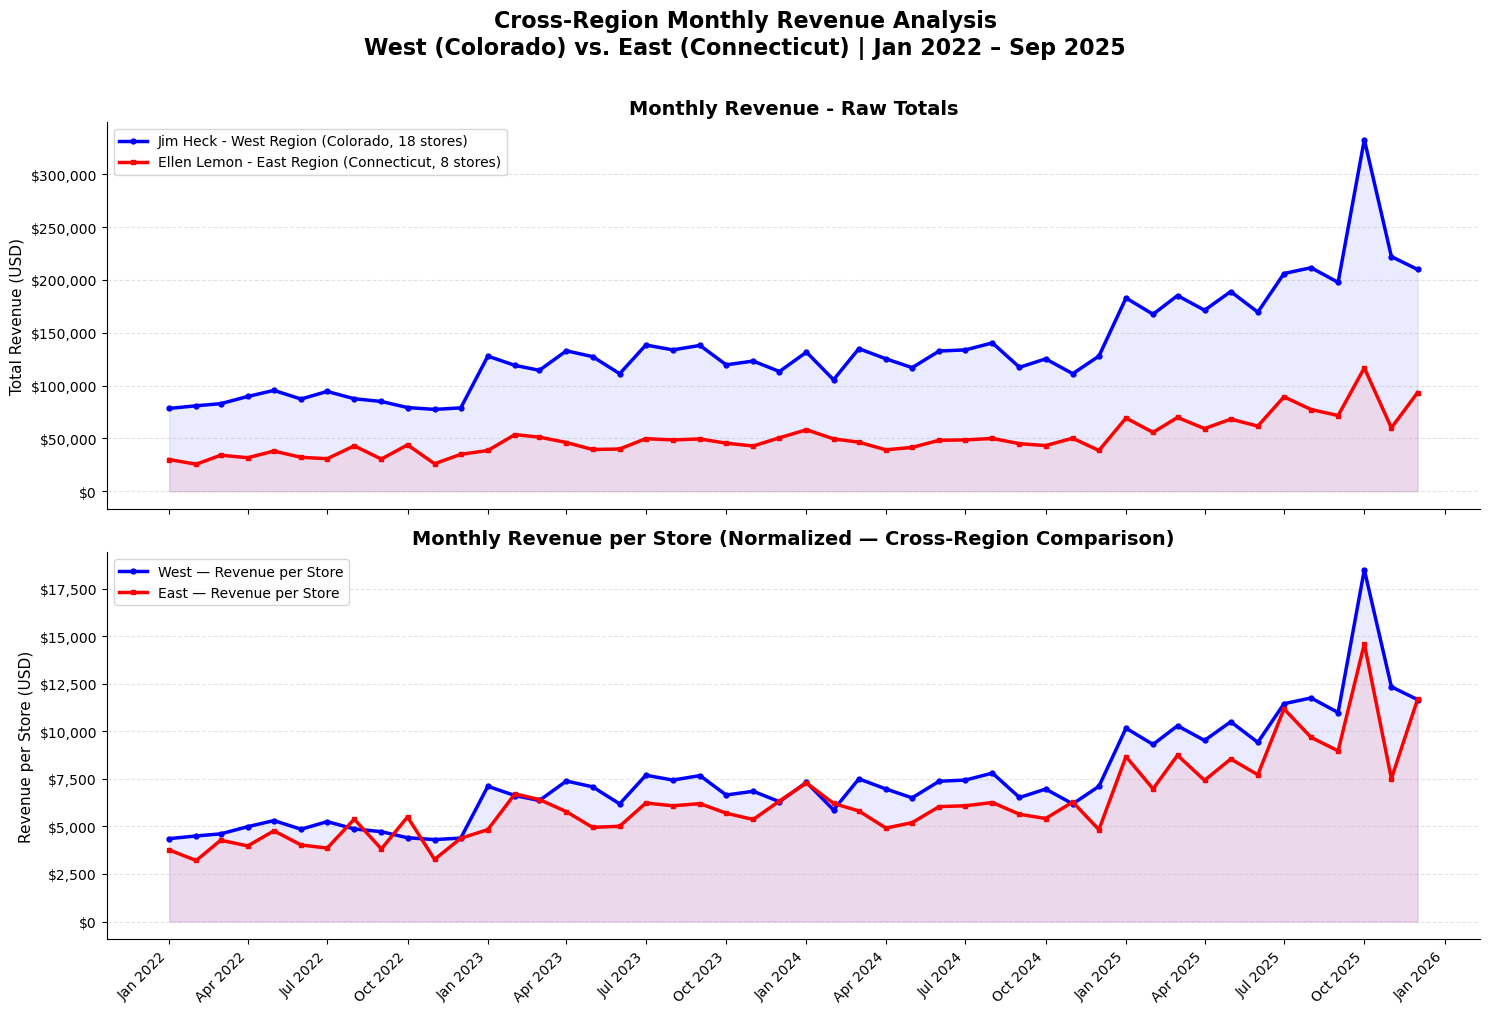

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)


# Raw Monthly Revenue

axes[0].plot(monthly['Date'], monthly['West_Revenue'],
             color='blue', linewidth=2.5, marker='o', markersize=3.5,
             label='Jim Heck - West Region (Colorado, 18 stores)')
axes[0].plot(monthly['Date'], monthly['East_Revenue'],
             color='red', linewidth=2.5, marker='s', markersize=3.5,
             label='Ellen Lemon - East Region (Connecticut, 8 stores)')
axes[0].fill_between(monthly['Date'], monthly['West_Revenue'], alpha=0.08, color='blue')
axes[0].fill_between(monthly['Date'], monthly['East_Revenue'], alpha=0.08, color='red')

axes[0].set_title("Monthly Revenue - Raw Totals", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Total Revenue (USD)", fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.35)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# Revenue per store (normalized, cross-region comparison)

axes[1].plot(monthly['Date'], monthly['Rev_Per_Store_West'],
             color='blue', linewidth=2.5, marker='o', markersize=3.5,
             label='West — Revenue per Store')
axes[1].plot(monthly['Date'], monthly['Rev_Per_Store_East'],
             color='red', linewidth=2.5, marker='s', markersize=3.5,
             label='East — Revenue per Store')
axes[1].fill_between(monthly['Date'], monthly['Rev_Per_Store_West'],  alpha=0.08, color='blue')
axes[1].fill_between(monthly['Date'], monthly['Rev_Per_Store_East'], alpha=0.08, color='red')

axes[1].set_title("Monthly Revenue per Store (Normalized — Cross-Region Comparison)",
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel("Revenue per Store (USD)", fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1].legend(fontsize=10, loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.35)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle("Cross-Region Monthly Revenue Analysis\nWest (Colorado) vs. East (Connecticut) | Jan 2022 – Sep 2025",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue_crossregion.png', dpi=150, bbox_inches='tight')
plt.show()


### CHART 2: Store Revenue Rankings 

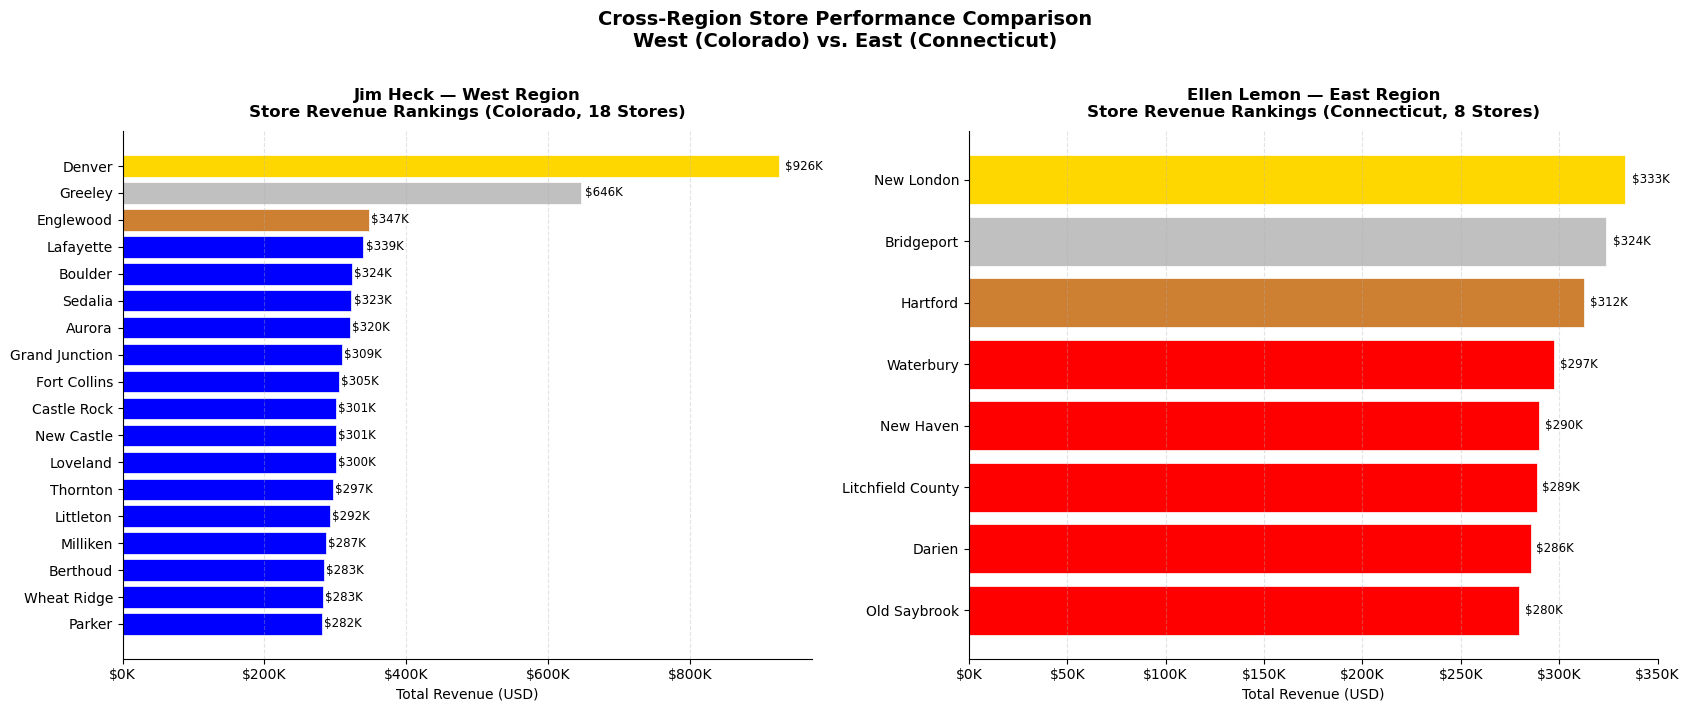

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

def store_bar(ax, rank_df, color, title):
    df = rank_df.reset_index(drop=True).sort_values('Total Revenue')
    colors = [color if i < len(df)-3 else ('gold' if i==len(df)-1 
              else 'silver' if i==len(df)-2 else '#CD7F32') for i in range(len(df))]
    bars = ax.barh(df['Store Location'], df['Total Revenue'], color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, df['Total Revenue']):
        ax.text(bar.get_width() + val*0.01, bar.get_y() + bar.get_height()/2,
                f'${val/1e3:.0f}K', va='center', fontsize=8.5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Total Revenue (USD)", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

store_bar(axes[0], jim_rank, 'blue',
          "Jim Heck — West Region\nStore Revenue Rankings (Colorado, 18 Stores)")
store_bar(axes[1], ellen_rank, 'red',
          "Ellen Lemon — East Region\nStore Revenue Rankings (Connecticut, 8 Stores)")

fig.suptitle("Cross-Region Store Performance Comparison\nWest (Colorado) vs. East (Connecticut)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart2_store_rankings_crossregion.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross Region Analysis - Final Summary 

In this analysis, I compared two EmporiUm territories from different regions — Jim Heck's West Region (Colorado) and Ellen Lemon's East Region (Connecticut) — across 335,000+ transactions from January 2022 through September 2025.

### Key Cross-Region Takeaways

| Finding | West (Colorado) | East (Connecticut) |
|---|---|---|
| **Revenue** | Tech & Accessories (71%) | Tech & Accessories (71%) |
| **Seasonal pattern** | Aug–Sep + Jan spikes | Aug–Sep + Jan spikes |
| **Store consistency** | Wide spread (Denver outlier) | Very consistent across all stores |
| **Store avg**   | 356K | 299K |
| **Rewards coverage** | ~10% | ~10% |
| **Growth trend** | Positive | Positive |


The identical category mix and seasonal pattern across two geographically separate regions confirms these are student-driven purchasing behaviors and not regional preferences. This means marketing campaigns can be designed once and deployed cross-regionally with high confidence of effectiveness in both regions.

The single biggest cross-region opportunity is growing rewards program enrollment from ~10% to 25%+, which would unlock the customer data needed to make marketing more targeted and effective.